<a href="https://colab.research.google.com/github/ChiranthanM512/-Spotify-Music-Clustreing/blob/main/placement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [3]:
df.isnull().sum()

,0
genre,0
artist_name,0
track_name,0
track_id,0
popularity,0
acousticness,0
danceability,0
duration_ms,0
energy,0
instrumentalness,1


In [4]:
df = df.dropna()

In [5]:
features = df[['danceability','energy','tempo','loudness','valence']]

In [6]:
df['energy_level'] = pd.cut(df['energy'],
                           bins=[0,0.3,0.6,1],
                           labels=['Low','Medium','High'])

In [7]:
df['tempo_category'] = pd.cut(df['tempo'],
                              bins=[0,90,120,200],
                              labels=['Slow','Medium','Fast'])

Text(0.5, 1.0, 'Danceability Distribution')

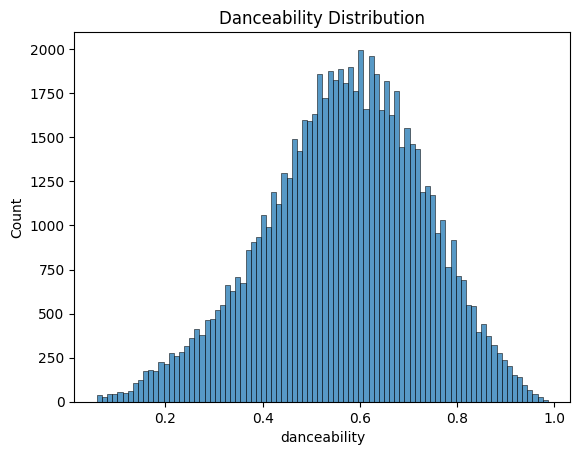

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['danceability'])
plt.title("Danceability Distribution")

<Axes: >

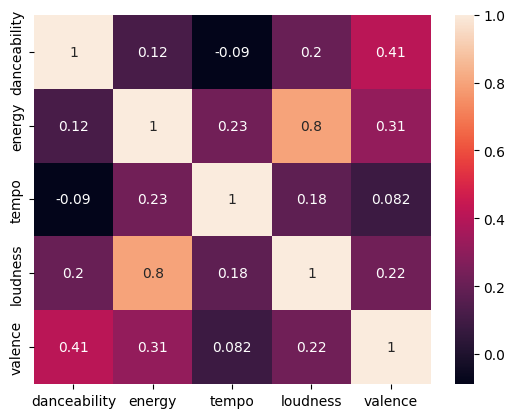

In [9]:
sns.heatmap(features.corr(), annot=True)

<Axes: xlabel='energy', ylabel='danceability'>

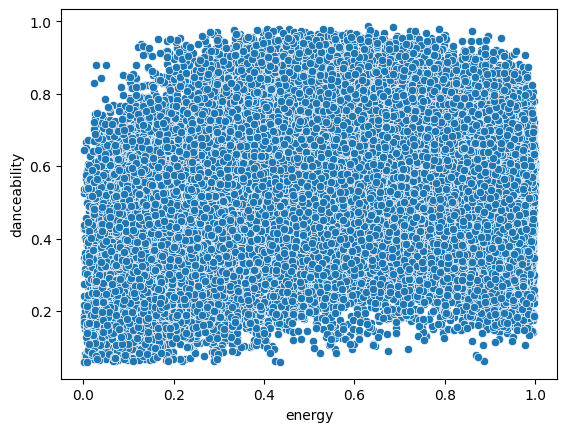

In [10]:
sns.scatterplot(x='energy', y='danceability', data=df)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

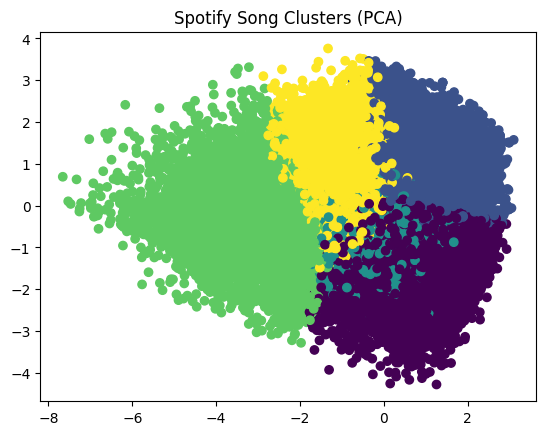

In [14]:
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'])
plt.title("Spotify Song Clusters (PCA)")
plt.show()

In [17]:
import numpy as np

sample_size = 5000
indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[indices]

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(X_sample)

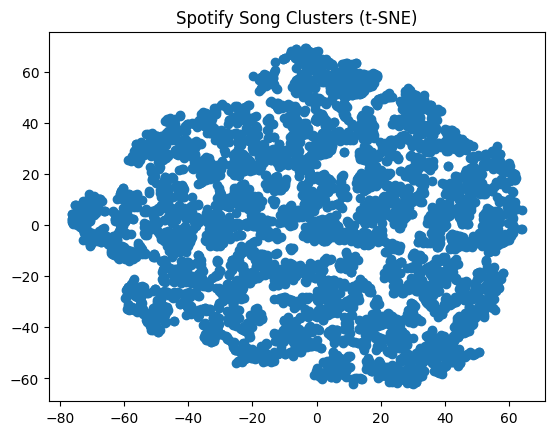

In [18]:
plt.scatter(tsne_result[:,0], tsne_result[:,1])
plt.title("Spotify Song Clusters (t-SNE)")
plt.show()

In [19]:
df.groupby('Cluster')[features.columns].mean()

,danceability,energy,tempo,loudness,valence
Cluster,,,,,
0,0.464263,0.772655,160.262288,-5.791961,0.457748
1,0.702437,0.721200,118.696978,-6.645555,0.741048
2,0.531955,0.766883,103.713508,-5.600538,0.368173
3,0.359988,0.220429,107.263904,-16.141709,0.202028
4,0.643413,0.421097,113.743519,-10.500070,0.407652


In [20]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

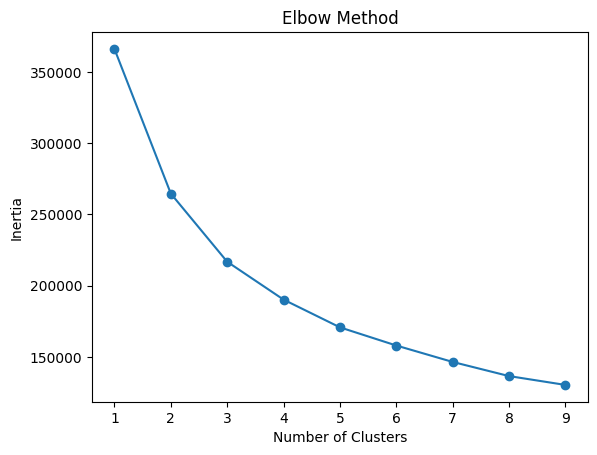

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.19694090966255964


In [23]:
def recommend(song_name):

    cluster = df[df['track_name']==song_name]['Cluster'].values[0]

    recommendations = df[df['Cluster']==cluster]['track_name'].head(10)

    return recommendations

In [24]:
import pandas as pd

# Save the clustered DataFrame to a CSV file
df.to_csv("spotify_tracks_clustered.csv", index=False)